<a href="https://colab.research.google.com/github/kimdesok/I-JEPA/blob/main/I_JEPA_Tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q transformers accelerate
!pip install -q torchstain

In [2]:
import torch
import torch.nn as nn
import requests
import urllib3

import os

import matplotlib.pyplot as plt
import numpy as np

from PIL import Image
from io import BytesIO
from IPython.display import display
from transformers import AutoImageProcessor, IJepaModel, IJepaForImageClassification
from sklearn.manifold import TSNE

# Suppress the InsecureRequestWarning
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

RUN_MODE = "Deep Full"  # Set Deep Full for the deep
TEST_MODE = False # True for the inference only

In [3]:
# Load model and processor (example using ViT-Huge)
model_id = "facebook/ijepa_vith14_1k"
processor = AutoImageProcessor.from_pretrained(model_id)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = IJepaModel.from_pretrained(model_id).to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/325 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


config.json:   0%|          | 0.00/497 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.52G [00:00<?, ?B/s]

In [4]:
# Prepare a sample image
def fetch_images(url, title):

  # Wikimedia requires a User-Agent to avoid a 403 error
  headers = {'User-Agent': 'I-JEPA-Tutorial-Script/1.0'}

  # Use BytesIO to wrap the content for PIL
  try:
    response = requests.get(url, headers=headers)
    response.raise_for_status()

    image = Image.open(BytesIO(response.content)).convert("RGB")
    resized = image.resize((224,224))
    print(resized.size)
    display(resized)
    resized.save(f"/content/sample_data/{title}")
    return resized
  except Exception as e:
        print(f"Failed to process image: {e}")
        return None

def load_images(im_path):
  valid_extensions = ('.png', '.jpg', '.jpeg', '.bmp', '.tiff')
  if im_path.lower().endswith(valid_extensions):
    try:
      resized = Image.open(im_path).convert("RGB")
      return resized
    except Exception as e:
      print(f"Failed to process image: {e}")
      return None

In [5]:
import os
import pandas as pd
import time
import joblib

# Data preparation
from torch.utils.data import TensorDataset, DataLoader
from torch.utils.data import Dataset, DataLoader

class ImageFeatureDataset(Dataset):
    def __init__(self, data, processor, im_dir=None, label_col='label'):
        self.data = data
        self.processor = processor
        self.im_dir = im_dir
        self.label_col = label_col
        # Detect if we are using Hugging Face (PCam) or Pandas (MHIST)
        self.is_hf = not isinstance(data, pd.DataFrame)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        if self.is_hf:
            # Hugging Face PCam format: data[idx] returns {'image': PIL, 'label': 0/1}
            item = self.data[idx]
            image = item['image']
            label = item[self.label_col]
        else:
            # MHIST Pandas format
            row = self.data.iloc[idx]
            full_path = os.path.join(self.im_dir, row['Image Name'])
            image = load_images(full_path)
            label = row[self.label_col]

        if image is None: return None

        # Ensure image is RGB (PCam images are sometimes handled differently)
        if image.mode != 'RGB':
            image = image.convert('RGB')

        pixel_values = self.processor(images=image, return_tensors="pt")['pixel_values'].squeeze(0)
        return pixel_values, label

def get_dataset_tensors(filtered_df, encoder, label_col, current_im_dir=None):
    # Pass the dynamic labels and directory to the dataset
    dataset = ImageFeatureDataset(filtered_df, processor, im_dir=current_im_dir, label_col=label_col)

    # Use num_workers=0 if you encounter "PicklingError" with Hugging Face on Windows/Colab
    loader = DataLoader(dataset, batch_size=64, num_workers=4, pin_memory=True)

    embs, lbls = [], []
    model.eval()

    with torch.no_grad():
        for batch in loader:
            if batch is None: continue
            batch_pixels, batch_raw_labels = batch
            batch_pixels = batch_pixels.to(device)

            outputs = model(batch_pixels)

            # I-JEPA Feature Extraction (mean pooling)
            batch_emb = outputs.last_hidden_state.mean(dim=1).cpu().numpy()
            embs.append(batch_emb)

            # Support both numeric and string labels via the encoder
            lbls.extend(encoder.transform(batch_raw_labels))

    return torch.tensor(np.vstack(embs)).float(), torch.tensor(np.array(lbls)).long()


# **Create embeddings/encoder or Load them**

In [6]:
from datasets import load_dataset
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

DATASET = "PCam" #MHIST
label_encoder = LabelEncoder()

if(DATASET == "PCam"):
  # Load PCam dataset from Hugging Face
  # You can use "1aurent/PatchCamelyon" or "zacharielegault/PatchCamelyon"
  local_path = "/content/pcam_data"
  df = load_dataset("1aurent/PatchCamelyon", cache_dir=local_path)
  #print(df)

  # Access the predefined splits after converting them to pandas dataFrame
  train_df = df['train']
  test_df = df['test']

  save_dir = "/content/drive/MyDrive/I_JEPA_Project/embeddings_PCam/"

  #print(train_df)
  LABEL_COL = 'label'

  # Extract unique labels from the 'train' split
  unique_labels = set(train_df[LABEL_COL])
  label_encoder.fit(list(unique_labels))

elif(DATASET == "MHIST"):
  im_dir ="/content/drive/MyDrive/I_JEPA_Project/datasets/MHIST/images"
  anno_path = "/content/drive/MyDrive/I_JEPA_Project/datasets/MHIST/annotations.csv"

  # Load annotations (Assuming columns: 'filename' and 'label')
  df = pd.read_csv(anno_path)

  # Sampling image files after shuffling when code testing
  #shuffled_df = df.sample(frac=1, random_state=42).head(2000)

  # Filter rows based on labels in the 'split' column (or whichever column has 'train'/'test')
  train_df = df[df['Partition'] == 'train']
  test_df = df[df['Partition'] == 'test']

  save_dir = "/content/drive/MyDrive/I_JEPA_Project/embeddings_MHIST/"

  LABEL_COL = 'Majority Vote Label'
  label_encoder.fit(df[LABEL_COL].unique())

os.makedirs(save_dir, exist_ok=True)

# Define file paths
paths = {
    "X_train": os.path.join(save_dir, "X_train.pt"),
    "y_train": os.path.join(save_dir, "y_train.pt"),
    "X_test": os.path.join(save_dir, "X_test.pt"),
    "y_test": os.path.join(save_dir, "y_test.pt"),
    "encoder": os.path.join(save_dir, "label_encoder.pkl")
}

# Check if all files exist
files_exist = all(os.path.exists(p) for p in paths.values())

if files_exist:
    print("🚀 Existing embeddings found! Loading from Google Drive...")

    # Load Tensors
    X_train = torch.load(paths["X_train"], weights_only=True)
    y_train = torch.load(paths["y_train"], weights_only=True)
    X_test = torch.load(paths["X_test"], weights_only=True)
    y_test = torch.load(paths["y_test"], weights_only=True)

    # Load Encoder
    label_encoder = joblib.load(paths["encoder"])

    print(f"Loaded {len(X_train)} train samples and {len(X_test)} test samples.")

else:
    print("🔍 Embeddings & encoder not found. Starting feature extraction (this may take 10+ mins)...")

    # Pass the LABEL_COL and im_dir (which will be None for PCam)
    if DATASET == "PCam":
        X_train, y_train = get_dataset_tensors(train_df, label_encoder, LABEL_COL)
        X_test, y_test = get_dataset_tensors(test_df, label_encoder, LABEL_COL)
    elif DATASET == "MHIST":
        X_train, y_train = get_dataset_tensors(train_df, label_encoder, LABEL_COL, im_dir)
        X_test, y_test = get_dataset_tensors(test_df, label_encoder, LABEL_COL, im_dir)

    # --- Step 3: Save for next time ---
    torch.save(X_train, paths["X_train"])
    torch.save(y_train, paths["y_train"])
    torch.save(X_test, paths["X_test"])
    torch.save(y_test, paths["y_test"])
    joblib.dump(label_encoder, paths["encoder"])

    print("✅ Extraction complete and files saved to Google Drive.")

# Verification
print(f"Final shapes: X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"Classes: {label_encoder.classes_}")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00013-4717c3cf92578c(…):   0%|          | 0.00/471M [00:00<?, ?B/s]

data/train-00001-of-00013-549914845b4273(…):   0%|          | 0.00/471M [00:00<?, ?B/s]

data/train-00002-of-00013-a859720d3cfceb(…):   0%|          | 0.00/470M [00:00<?, ?B/s]

data/train-00003-of-00013-a70975735603ee(…):   0%|          | 0.00/470M [00:00<?, ?B/s]

...

data/test-00001-of-00002-3bfa172e8818685(…):   0%|          | 0.00/375M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/262144 [00:00<?, ? examples/s]

Generating valid split:   0%|          | 0/32768 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/32768 [00:00<?, ? examples/s]

🚀 Existing embeddings found! Loading from Google Drive...
Loaded 262144 train samples and 32768 test samples.
Final shapes: X_train: torch.Size([262144, 1280]), X_test: torch.Size([32768, 1280])
Classes: [False  True]


In [7]:
import seaborn as sns
import numpy as np
import pandas as pd
import torch
from cuml.decomposition import PCA as cuPCA
from cuml.manifold import TSNE as cuTSNE

import pandas as pd
import numpy as np
import torch
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

if(RUN_MODE != "Deep Full"):
    # Safely move data to CPU and convert to NumPy
    X_combined = torch.cat([X_train, X_test], dim=0).detach().cpu().numpy()

    # PCA Preprocessing (The "lost" step to reduce compute time)
    # Reducing to 50 dimensions before t-SNE is a standard speed optimization
    pca = PCA(n_components=50, random_state=42)
    X_pca = pca.fit_transform(X_combined)

    # Standard t-SNE (Scikit-learn version)
    # Using init='pca' can also help with stability and speed
    tsne = TSNE(n_components=2, perplexity=30, init='pca', random_state=42)
    embeddings_2d = tsne.fit_transform(X_pca)

    # Prepare labels and split identifiers
    train_labels = label_encoder.inverse_transform(y_train.cpu().numpy())
    test_labels = label_encoder.inverse_transform(y_test.cpu().numpy())

    combined_labels = np.concatenate([train_labels, test_labels])
    split_tags = ['Train'] * len(train_labels) + ['Test'] * len(test_labels)

    # Build the final DataFrame for Seaborn plotting
    tsne_df = pd.DataFrame({
        'x': embeddings_2d[:, 0],
        'y': embeddings_2d[:, 1],
        'Class': combined_labels,
        'Split': split_tags
    })


Visualize the Embeddings (t-SNE)

In [1]:
if(RUN_MODE!="x"):
  plt.figure(figsize=(10, 8))

  # Map hue to Class (Color) and style to Split (Marker Shape)
  # 'o' is solid circle, '$\circ$' is a TeX-style hollow circle
  sns.scatterplot(
      data=tsne_df,
      x='x',
      y='y',
      hue='Class',
      style='Split',
      markers={'Train': 'o', 'Test': '$\\circ$'},
      palette='viridis',
      s=100,
      alpha=0.7
  )

  plt.title("I-JEPA Embeddings: Train vs Test Distribution")
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
  plt.tight_layout()
  plt.show()

NameError: name 'RUN_MODE' is not defined

In [9]:
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, precision_recall_fscore_support
)
import seaborn as sns
import matplotlib.pyplot as plt

import torch.nn as nn
import torch.nn.functional as F

def evaluate_full_performance(model, X_test, y_test, encoder):
    model.eval()
    with torch.no_grad():
      X_test_dev = X_test.to(device)
      logits = model(X_test_dev)
      probs = F.softmax(logits, dim=1).cpu().numpy()
      preds = torch.argmax(logits, dim=1).cpu().numpy()
      y_true = y_test.numpy()

      # Classification Report (Precision, Recall, F1)
      target_names = [str(c) for c in encoder.classes_]
      report = classification_report(y_true, preds, target_names=target_names)
      #report = classification_report(y_true, preds, target_names=encoder.classes_)
      print("\n--- Classification Report ---\n")
      print(report)

      # ROC-AUC Score
      # For binary classification, we use the probability of the positive class
      if len(encoder.classes_) == 2:
          auc = roc_auc_score(y_true, probs[:, 1])
      else:
          auc = roc_auc_score(y_true, probs, multi_class='ovr')
      print(f"ROC-AUC Score: {auc:.4f}")

      # Confusion Matrix Visualization
      cm = confusion_matrix(y_true, preds)
      plt.figure(figsize=(8, 6))
      sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                  xticklabels=encoder.classes_, yticklabels=encoder.classes_)
      plt.xlabel('Predicted')
      plt.ylabel('Actual')
      plt.title('Confusion Matrix')
      plt.show()

# **Linear Probing**

In [10]:
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

class LinearProbe(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(LinearProbe, self).__init__()
        # The only trainable part of our system:
        self.fc = nn.Linear(input_dim, num_classes)

    def forward(self, x):
        return self.fc(x)

if(RUN_MODE!="Deep Full"):
  # Use already filtered tensors ---
  # num_classes was determined by fitting the label_encoder globally
  num_classes = len(label_encoder.classes_)

  # --- Step B: Create DataLoader for Training ---
  # Only the training data needs to be batched and shuffled
  train_dataset = TensorDataset(X_train, y_train)
  train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

  # --- Step C: Initialize the Linear Probe ---
  input_dim = X_train.shape[1]  # Should be 1280 for I-JEPA ViT-H/14
  model_probe = LinearProbe(input_dim, num_classes).to(device)

  criterion = nn.CrossEntropyLoss()
  optimizer = optim.Adam(model_probe.parameters(), lr=0.05)

  print(f"Ready to train on {len(X_train)} samples, validating on {len(X_test)} samples.")

Ready to train on 262144 samples, validating on 32768 samples.


In [11]:
import time

if(RUN_MODE!="Deep Full"):
  # Training Configuration
  patience = 15
  min_delta = 0.0005
  best_loss = float('inf')
  counter = 0
  num_epochs = 50 # Increased epochs since early stopping will handle the exit
  model_path = "/content/drive/MyDrive/I_JEPA_Project/models/best_linear_probe_pcam.pth"

  start_t = time.time()

  for epoch in range(num_epochs):
      # --- Training Phase ---
      model_probe.train()
      running_loss = 0.0
      for inputs, labels in train_loader:
          inputs, labels = inputs.to(device), labels.to(device)

          optimizer.zero_grad()
          outputs = model_probe(inputs)
          loss = criterion(outputs, labels)
          loss.backward()
          optimizer.step()
          running_loss += loss.item()

      avg_train_loss = running_loss / len(train_loader)

      # --- Validation Phase ---
      model_probe.eval()

      with torch.no_grad():
          val_logits = model_probe(X_test.to(device))
          val_preds = torch.argmax(val_logits, dim=1)
          val_acc = (val_preds == y_test.to(device)).float().mean().item()

          #val_outputs = model_probe(X_test.to(device))
          val_loss = criterion(val_logits, y_test.to(device)).item()

      print(f'Epoch {epoch+1}: Train Loss: {avg_train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2%}')

      # --- Early Stopping & Saving Best Model ---
      if val_loss < best_loss - min_delta:
          best_loss = val_loss
          torch.save(model_probe.state_dict(), model_path)
          counter = 0
          print("  --> New best model saved!")
      else:
          counter += 1
          if counter >= patience:
              print(f"Early stopping triggered at epoch {epoch+1}")
              break

  # Load the best weights for final evaluation
  model_probe.load_state_dict(torch.load(model_path))
  print(f"Finished Training in {time.time()-start_t:.2f}s. Best Val Loss: {best_loss:.4f}")

In [12]:
if(RUN_MODE!="Deep Full"):
  model_probe.eval()
  with torch.no_grad():
      X_test_dev, y_test_dev = X_test.to(device), y_test.to(device)
      outputs = model_probe(X_test_dev)
      _, predicted = torch.max(outputs, 1)

      evaluate_full_performance(model_probe, X_test, y_test, label_encoder)

  #print(f'Final Accuracy on Test Set: {accuracy:.2f}%')

## **Deep Probe (MLP)**
- also called a "Deep Linear Probe" or "Non-Linear Probe")
- refers to adding multiple non-linear layers on top of frozen embeddings

In [13]:
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Training Configuration
patience = 15
min_delta = 0.0005
best_loss = float('inf')
counter = 0
num_epochs = 50 # Increased epochs since early stopping will handle the exit

learning_rate = 1e-6
drop_out = 0.5

class DeepProbe(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(DeepProbe, self).__init__()
        # Layer 1: Expansion/High-dim mapping
        self.fc1 = nn.Linear(input_dim, 1024)
        self.dropout = nn.Dropout(drop_out) # Higher dropout for medical imaging
        self.bn1 = nn.BatchNorm1d(1024)  # Batch Normalization

        # Layer 2: Feature refinement
        self.fc2 = nn.Linear(1024, 128)
        self.dropout = nn.Dropout(drop_out) # Higher dropout for medical imaging
        self.bn2 = nn.BatchNorm1d(128)

        # Layer 3: Bottleneck for classification
        self.fc3 = nn.Linear(128, 32)
        self.dropout = nn.Dropout(drop_out) # Higher dropout for medical imaging
        self.output = nn.Linear(32, num_classes)

    def forward(self, x):
        x = F.leaky_relu(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        x = F.leaky_relu(self.bn2(self.fc2(x)))
        x = self.dropout(x)
        x = F.leaky_relu(self.fc3(x))
        return self.output(x)

# Initialize
model_probe = DeepProbe(X_train.shape[1], len(label_encoder.classes_)).to(device)
# Use a slightly lower learning rate for deep probes to avoid early divergence
optimizer = torch.optim.AdamW(model_probe.parameters(), lr=learning_rate, weight_decay=1e-2)
# 'min' mode monitors for loss reduction; 'patience' is the number of stagnant epochs
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

In [14]:
# Calculate weights: Higher weight for the minority/harder class
# If Class 0 (SSA) is hard, increase its weight
class_weights = torch.tensor([1.0, 1.0]).to(device) # Example: SSA gets 2x importance
criterion = nn.CrossEntropyLoss(weight=class_weights)

In [15]:
model_path = "/content/drive/MyDrive/I_JEPA_Project/models/best_deep_probe_pcam.pth"
if os.path.exists(model_path):
    os.remove(model_path)  # Explicitly remove the old file first
start_t = time.time()

if(RUN_MODE!="x"):
  for epoch in range(num_epochs):
      # --- Training Phase ---
      model_probe.train()
      running_loss = 0.0
      for inputs, labels in train_loader:
          inputs, labels = inputs.to(device), labels.to(device)

          optimizer.zero_grad()
          outputs = model_probe(inputs)
          loss = criterion(outputs, labels)
          loss.backward()
          optimizer.step()
          running_loss += loss.item()

      avg_train_loss = running_loss / len(train_loader)

      # --- Validation Phase ---
      model_probe.eval()

      with torch.no_grad():
          val_logits = model_probe(X_test.to(device))
          val_preds = torch.argmax(val_logits, dim=1)
          val_acc = (val_preds == y_test.to(device)).float().mean().item()

          #val_outputs = model_probe(X_test.to(device))
          val_loss = criterion(val_logits, y_test.to(device)).item()

          #Step the scheduler with the validation loss
          scheduler.step(val_loss)

          # Get current LR to replace the missing verbose output
          current_lr = optimizer.param_groups[0]['lr']
          print(f"Epoch {epoch}: Current Learning Rate: {current_lr}")

      print(f'Epoch {epoch+1}: Train Loss: {avg_train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2%}')

      # --- Early Stopping & Saving Best Model ---
      if val_loss < best_loss - min_delta:
          best_loss = val_loss
          torch.save(model_probe.state_dict(), model_path)
          counter = 0
          print("  --> New best model saved!")
      else:
          counter += 1
          if counter >= patience:
              print(f"Early stopping triggered at epoch {epoch+1}")
              break

  print(f"Finished Training in {time.time()-start_t:.2f}s. Best Val Loss: {best_loss:.4f}")

Epoch 0: Current Learning Rate: 1e-06
Epoch 1: Train Loss: 0.5596 | Val Loss: 0.4912 | Val Acc: 79.52%
  --> New best model saved!
Epoch 1: Current Learning Rate: 1e-06
Epoch 2: Train Loss: 0.4455 | Val Loss: 0.4317 | Val Acc: 81.05%
  --> New best model saved!
Epoch 2: Current Learning Rate: 1e-06
Epoch 3: Train Loss: 0.3881 | Val Loss: 0.4058 | Val Acc: 81.89%
  --> New best model saved!
Epoch 3: Current Learning Rate: 1e-06
Epoch 4: Train Loss: 0.3544 | Val Loss: 0.3944 | Val Acc: 81.83%
  --> New best model saved!
Epoch 4: Current Learning Rate: 1e-06
Epoch 5: Train Loss: 0.3330 | Val Loss: 0.3939 | Val Acc: 81.94%
  --> New best model saved!
Epoch 5: Current Learning Rate: 1e-06
Epoch 6: Train Loss: 0.3169 | Val Loss: 0.3829 | Val Acc: 82.46%
  --> New best model saved!
Epoch 6: Current Learning Rate: 1e-06
Epoch 7: Train Loss: 0.3054 | Val Loss: 0.3851 | Val Acc: 82.38%
Epoch 7: Current Learning Rate: 1e-06
Epoch 8: Train Loss: 0.2963 | Val Loss: 0.3874 | Val Acc: 82.33%
Epoch 8:


--- Classification Report ---

              precision    recall  f1-score   support

       False       0.78      0.90      0.84     16391
        True       0.88      0.75      0.81     16377

    accuracy                           0.82     32768
   macro avg       0.83      0.82      0.82     32768
weighted avg       0.83      0.82      0.82     32768

ROC-AUC Score: 0.9152


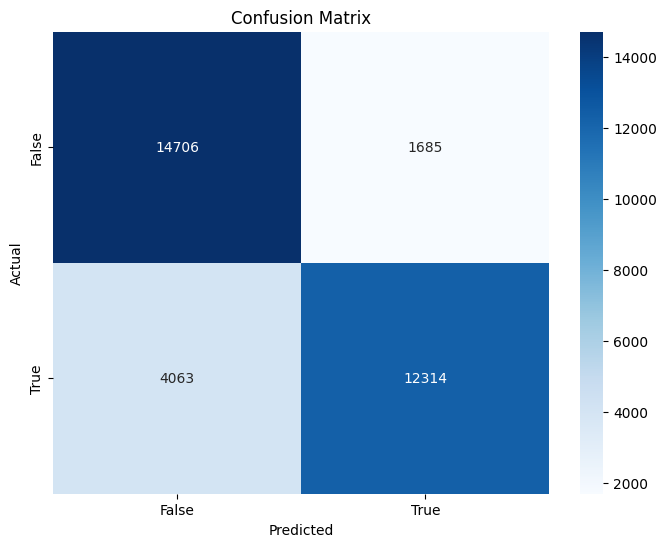

In [16]:
#model_path = "/content/drive/MyDrive/I_JEPA_Project/models/best_deep_probe_pcam_81.pth"

if(RUN_MODE!="x"):
   # Load the best weights for final evaluation

  model_probe.load_state_dict(torch.load(model_path))
  model_probe.eval()
  with torch.no_grad():
      X_test_dev, y_test_dev = X_test.to(device), y_test.to(device)
      outputs = model_probe(X_test_dev)
      _, predicted = torch.max(outputs, 1)

      evaluate_full_performance(model_probe, X_test, y_test, label_encoder)

  #print(f'Final Accuracy on Test Set: {accuracy:.2f}%')

## **Deep_Full : End-to-end finetuning model**

In [17]:
# backbone
#from transformers import
#import torch.optim as

# Hyperparameter settings
lr_backbone = 1e-6       # Learning rate for the backbone model
lr_head = 1e-3           # Learning rate for head model

accumulation_steps = 6 # Effectively results in a batch size of batch_size * accumulation_steps

best_val_loss = float('inf')

patience = 10
counter = 0
num_epochs = 50

model_path = "/content/drive/MyDrive/I_JEPA_Project/models/best_deep_full_pcam_aug.pth"

class IJepaFullModel(nn.Module):
    def __init__(self, backbone_id, head_object):
        super(IJepaFullModel, self).__init__()
        # Load the pre-trained I-JEPA backbone
        self.backbone = IJepaModel.from_pretrained(backbone_id)
        # Use the existing DeepProbe object as the head
        self.head = head_object

    def forward(self, pixel_values):
        # Forward through I-JEPA backbone
        outputs = self.backbone(pixel_values)

        # Extract and pool the hidden states (Average Pooling)
        # last_hidden_state shape: [batch, sequence_length, 1280]
        embeddings = outputs.last_hidden_state.mean(dim=1)

        # Forward through the DeepProbe head
        logits = self.head(embeddings)
        return logits

In [18]:
# Load the best weights for final evaluation
backbone_path = "/content/drive/MyDrive/I_JEPA_Project/models/best_deep_probe_pcam.pth"
model_probe.load_state_dict(torch.load(backbone_path))

# Initialize the combined model
# We use the same DeepProbe definition you just tested
my_head = DeepProbe(input_dim=1280, num_classes=len(label_encoder.classes_))
model_full = IJepaFullModel("facebook/ijepa_vith14_1k", my_head).to(device)

# Unfreeze everything for end-to-end training
model_full.backbone.requires_grad_(True)

# Differential Learning Rates
optimizer = optim.AdamW([
    {'params': model_full.backbone.parameters(), 'lr': lr_backbone}, # Ultra-low for backbone
    {'params': model_full.head.parameters(), 'lr': lr_head}      # Standard for head
], weight_decay=0.05)  # Higher weight decay prevents overfitting

# Calculate weights: Higher weight for the minority/harder class
# If Class 0 (SSA) is hard, increase its weight
class_weights = torch.tensor([1.0, 1.0]).to(device) # Example: SSA gets 2x importance
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Add a scheduler to lower LR as you approach convergence
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

In [19]:
from torchvision import transforms

train_transforms = transforms.Compose([

    # HSV & Color Jitter (Replaces the intensity/scale logic)
    # PCam needs specific color shifts to simulate different staining (H&E)
    transforms.ColorJitter(
        brightness=0.2, # Intensity scale shifts
        contrast=0.2,
        saturation=0.3, # Crucial for H&E staining variations
        hue=0.1         # Subtle shifts in Hematoxylin/Eosin colors
    ),

    # Standard I-JEPA normalization
    transforms.Resize((224, 224)), # Resize for ViT encoder
    #transforms.ToTensor(),
    #transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),

    # Geometry: PCam images are 96x96; rotating handles tissue direction
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=90), # Histology features are rotation-invariant

    # Geometric Shifts
    transforms.RandomAffine(
        degrees=0,
        translate=(0.1, 0.1), # Shifts
        scale=(0.9, 1.1)      # Intensity/scale manipulation
    )
])

## **Macenko Normalization**

In [20]:
import torchstain
import cv2

# Load a "Target" reference image (the ideal look you want)
# Use one of the best images in either class as the anchor
target_path = "/content/drive/MyDrive/I_JEPA_Project/target_image/inference_test_m.jpg"
target_img = cv2.cvtColor(cv2.imread(target_path), cv2.COLOR_BGR2RGB)

# Initialize and Fit the Macenko Normalizer
# Using the 'torch' backend allows this to run on the A100 GPU
normalizer = torchstain.normalizers.MacenkoNormalizer(backend='torch')
normalizer.fit(torch.tensor(target_img).permute(2, 0, 1).float()) # [C, H, W]

print("Macenko Normalizer fitted to target template.")


Macenko Normalizer fitted to target template.


In [21]:
class SafeMacenkoTorchstainTransform:
    def __init__(self, normalizer, use_gpu=False, fallback="identity"):
        self.normalizer = normalizer
        self.use_gpu = use_gpu and torch.cuda.is_available()
        self.fallback = fallback  # "identity" is usually best

    @torch.no_grad()
    def __call__(self, pil_img: Image.Image) -> Image.Image:
        img_np = np.array(pil_img, dtype=np.uint8)

        # quick guard: empty or weird shapes
        if img_np.ndim != 3 or img_np.shape[2] != 3 or img_np.size == 0:
            return pil_img.convert("RGB")

        t = torch.from_numpy(img_np).permute(2, 0, 1).float()

        if self.use_gpu:
            t = t.cuda(non_blocking=True)

        try:
            out = self.normalizer.normalize(t)
            if isinstance(out, (tuple, list)):
                out = out[0]

            out = out.clamp(0, 255).byte().permute(1, 2, 0).cpu().numpy()
            return Image.fromarray(out)

        except Exception:
            # Most common: blank/low-signal patches → empty ODhat → kthvalue error
            if self.fallback == "identity":
                return pil_img
            return pil_img  # keep it simple

In [22]:
from torch.utils.data import Dataset, DataLoader
import os
from PIL import Image

class HistologyFullDataset(Dataset):
    def __init__(self, data, processor, encoder, transform=None, macenko_transform=None):
        self.data = data
        self.processor = processor
        self.encoder = encoder
        self.transform = transform
        self.macenko_transform = macenko_transform
        self.is_hf = True

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"]  # HF datasets image is usually PIL already

        if image.mode != "RGB":
            image = image.convert("RGB")

        # Macenko
        if self.macenko_transform is not None:
            image = self.macenko_transform(image)

        # Image augmentations
        if self.transform:
            image = self.transform(image)

        # Processor -> pixel_values
        pixel_values = self.processor(image, return_tensors="pt")["pixel_values"].squeeze(0)

        label = torch.tensor(self.encoder.transform([item["label"]])[0]).long()
        return pixel_values, label

Data loading

In [23]:
macenko_tf = SafeMacenkoTorchstainTransform(normalizer, use_gpu=False)

if DATASET == "PCam":
    train_dataset = HistologyFullDataset(train_df, processor, label_encoder,
                                         train_transforms, macenko_tf)
    test_dataset = HistologyFullDataset(test_df, processor, label_encoder, None, macenko_tf)
else:
    train_dataset = HistologyFullDataset(train_df, processor, label_encoder,
                                         train_transforms, macenko_tf)
    test_dataset = HistologyFullDataset(test_df, processor, label_encoder, None, macenko_tf)

# Use batch_size 8 or 16 for E2E Fine-tuning (Huge models consume a lot of VRAM)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=4,
                          pin_memory=True, prefetch_factor=2, persistent_workers=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=4,
                         pin_memory=True, persistent_workers=True)

Training

In [24]:
from torch.amp import GradScaler, autocast

import torch.backends.cudnn as cudnn
cudnn.benchmark = True  # Significant speedup for static input shapes

if(not TEST_MODE):
  # Training Configuration
  #print(device.type, device)
  scaler = torch.amp.GradScaler(device.type)

  start_t = time.time()

  for epoch in range(num_epochs):
        # --- Training Phase ---
        model_full.train()
        running_loss = 0.0

        for i, (images, labels) in enumerate(train_loader):
          if images is None: # Skip if the batch is empty after filtering problematic images
              continue
          images, labels = images.to(device), labels.to(device)

          # Forward pass with Mixed Precision
          #with autocast(device):
          with torch.amp.autocast(device_type=device.type):
              outputs = model_full(images)
              loss = criterion(outputs, labels) / accumulation_steps

          # Backward pass
          scaler.scale(loss).backward()

          # Step optimizer only every N steps (Gradient Accumulation)
          if (i + 1) % accumulation_steps == 0:
              scaler.step(optimizer)
              scaler.update()
              optimizer.zero_grad()

          running_loss += loss.detach().item() * accumulation_steps

        avg_train_loss = running_loss / len(train_loader)

        # --- Validation ---
        model_full.eval()
        val_loss = 0.0
        # To correctly calculate avg_val_loss, we need to track how many non-None batches are processed.
        # Let's count valid batches.
        valid_test_batches = 0
        with torch.no_grad():
            for i, (images, labels) in enumerate(test_loader):
                if images is None: # Skip if the batch is empty after filtering problematic images
                    continue
                if i%5 != 0: # Only apply sampling after checking for None batch
                  continue
                images, labels = images.to(device), labels.to(device)
                with torch.amp.autocast(device_type=device.type):
                  val_outputs = model_full(images)
                  v_loss = criterion(val_outputs, labels)
                  val_loss += v_loss.item()
                valid_test_batches += 1

        # Ensure we don't divide by zero if all test batches were skipped
        avg_val_loss = val_loss / valid_test_batches if valid_test_batches > 0 else float('inf')
        print(f"Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} Val Loss: {avg_val_loss:.4f}")

        # Optional: Clear GPU cache between epochs to maintain speed
        torch.cuda.empty_cache()

        # --- Early Stopping & Checkpoint ---
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model_full.state_dict(), model_path)
            counter = 0
            print("  --> New best model saved!")
        else:
            counter += 1
            if counter >= patience:
                print("Early stopping triggered.")
                break

  print(f"Finished Training in {time.time()-start_t:.2f}s. Best Val Loss: {best_val_loss:.4f}")

Epoch 1 | Train Loss: 0.2701 Val Loss: 0.3221
  --> New best model saved!
Epoch 2 | Train Loss: 0.1862 Val Loss: 0.4414
Epoch 3 | Train Loss: 0.1595 Val Loss: 0.3460
Epoch 4 | Train Loss: 0.1435 Val Loss: 0.3806
Epoch 5 | Train Loss: 0.1324 Val Loss: 0.2763
  --> New best model saved!
Epoch 6 | Train Loss: 0.1235 Val Loss: 0.3821
Epoch 7 | Train Loss: 0.1164 Val Loss: 0.4326
Epoch 8 | Train Loss: 0.1092 Val Loss: 0.3282
Epoch 9 | Train Loss: 0.1048 Val Loss: 0.2667
  --> New best model saved!
Epoch 10 | Train Loss: 0.0998 Val Loss: 0.2884
Epoch 11 | Train Loss: 0.0947 Val Loss: 0.2973
Epoch 12 | Train Loss: 0.0910 Val Loss: 0.3474
Epoch 13 | Train Loss: 0.0872 Val Loss: 0.3285
Epoch 14 | Train Loss: 0.0850 Val Loss: 0.3555
Epoch 15 | Train Loss: 0.0825 Val Loss: 0.3475
Epoch 16 | Train Loss: 0.0793 Val Loss: 0.3108
Epoch 17 | Train Loss: 0.0766 Val Loss: 0.3380
Epoch 18 | Train Loss: 0.0748 Val Loss: 0.3607
Epoch 19 | Train Loss: 0.0720 Val Loss: 0.3521
Early stopping triggered.
Finish

Training

In [25]:
import torch
import torch.nn.functional as F

# Load the best weights for final evaluation
model_path = "/content/drive/MyDrive/I_JEPA_Project/models/best_deep_full_pcam_aug.pth"
model_full.load_state_dict(torch.load(model_path))

model_full.eval()
all_preds = []
all_labels = []
all_probs = []

print("🚀 Starting full-model evaluation on test set...")

with torch.no_grad():
    for images, labels in test_loader:
        # Move raw images and labels to GPU
        images, labels = images.to(device), labels.to(device)

        # Forward pass through the entire model (Backbone + Head)
        outputs = model_full(images)

        # Calculate probabilities and final predictions
        probs = F.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs, 1)

        # Collect results on CPU to save GPU memory
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

# Convert collected lists to standard NumPy arrays for metrics
y_true = np.array(all_labels)
y_pred = np.array(all_preds)
y_probs = np.array(all_probs)


🚀 Starting full-model evaluation on test set...



--- Classification Report ---

              precision    recall  f1-score   support

       False       0.86      0.95      0.91     16391
        True       0.95      0.85      0.90     16377

    accuracy                           0.90     32768
   macro avg       0.91      0.90      0.90     32768
weighted avg       0.91      0.90      0.90     32768

ROC-AUC Score: 0.9659


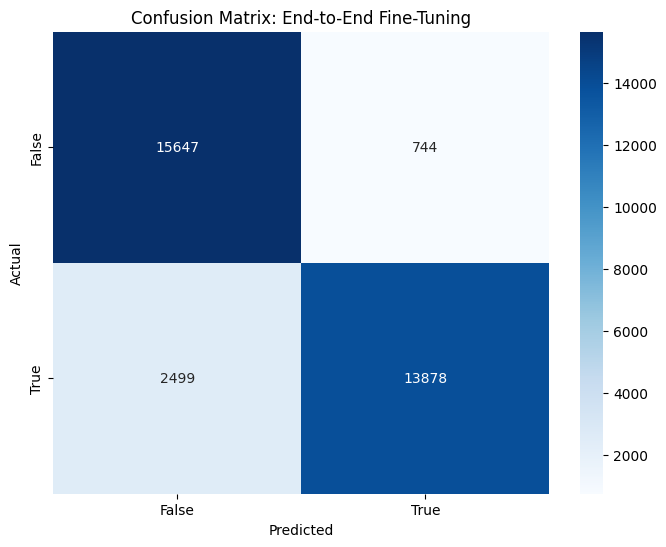

              precision    recall  f1-score   support

       False       0.86      0.95      0.91     16391
        True       0.95      0.85      0.90     16377

    accuracy                           0.90     32768
   macro avg       0.91      0.90      0.90     32768
weighted avg       0.91      0.90      0.90     32768



In [26]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_final_metrics(y_true, y_pred, y_probs, encoder):

    # Convert boolean labels to strings for classification_report
    target_names_str = [str(c) for c in encoder.classes_]

    # Standard Classification Report
    print("\n--- Classification Report ---\n")
    cr = classification_report(y_true, y_pred, target_names=target_names_str)
    print(cr)

    # ROC-AUC Calculation
    if len(encoder.classes_) == 2:
        auc = roc_auc_score(y_true, y_probs[:, 1])
    else:
        auc = roc_auc_score(y_true, y_probs, multi_class='ovr', average='macro')
    print(f"ROC-AUC Score: {auc:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names_str, yticklabels=target_names_str)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix: End-to-End Fine-Tuning')
    plt.show()

    return cr

# Final execution call
cr = evaluate_final_metrics(y_true, y_pred, y_probs, label_encoder)
print(cr)